# **Data Loading**

First you need to download the dataset from the link: https://data.mendeley.com/datasets/t9ndx37v5h/1

Then upload this dataset to your google drive

Then the dataset from your google drive will be fetched in this notebook

In [11]:
from google.colab import drive
import tensorflow as tf
import matplotlib.pyplot as plt
from collections import defaultdict

In [12]:
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
# The directory of the dataset in your google drive
dataset_dir = '/content/drive/MyDrive/Digital Knee X-ray Images/MedicalExpert-I'

In [14]:
class_names = ['0Normal', '1Doubtful', '2Mild', '3Moderate', '4Severe']

# **Pre-Processing**

In [15]:
train_split, val_split, test_split = 0.7, 0.2, 0.1

In [16]:
# Split the full dataset into train and val-test set.
train_dataset, val_test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
  dataset_dir,
  labels='inferred',
  label_mode='int',
  class_names=class_names,
  color_mode='rgb',
  batch_size=None,
  image_size=(160, 640),
  validation_split=0.3,
  subset='both',
  shuffle=True,
  seed=101,
  data_format='channels_last'
)

Found 1650 files belonging to 5 classes.
Using 1155 files for training.
Using 495 files for validation.


In [17]:
# Split the val-test set into validation and test set
val_test_dataset = val_test_dataset.shuffle(100)

val_size = int((val_split/(val_split+test_split)) * len(val_test_dataset))
val_dataset = val_test_dataset.take(val_size)
test_dataset = val_test_dataset.skip(val_size)

In [18]:
# Rescaling is neccessary before augmentation becuase the albumentations library expect the float number in the range (0-1)
rescale_layer = tf.keras.layers.Rescaling(1/255)

def rescale(image, label):
    image = rescale_layer(image)
    return image, label

train_dataset = train_dataset.map(rescale)
val_dataset = val_dataset.map(rescale)
test_dataset = test_dataset.map(rescale)

In [19]:
def get_class_count(dataset):
  # Dictionary to store class counts
  class_counts = defaultdict(int)

  # Iterate through the dataset
  for _, label in dataset:
      class_counts[int(label.numpy())] += 1

  # Print the results
  for class_label, count in sorted(class_counts.items()):
      print(f"Class {class_label}: {count} images")

In [20]:
# Class count before Augmentation
get_class_count(train_dataset)

Class 0: 355 images
Class 1: 337 images
Class 2: 172 images
Class 3: 156 images
Class 4: 135 images


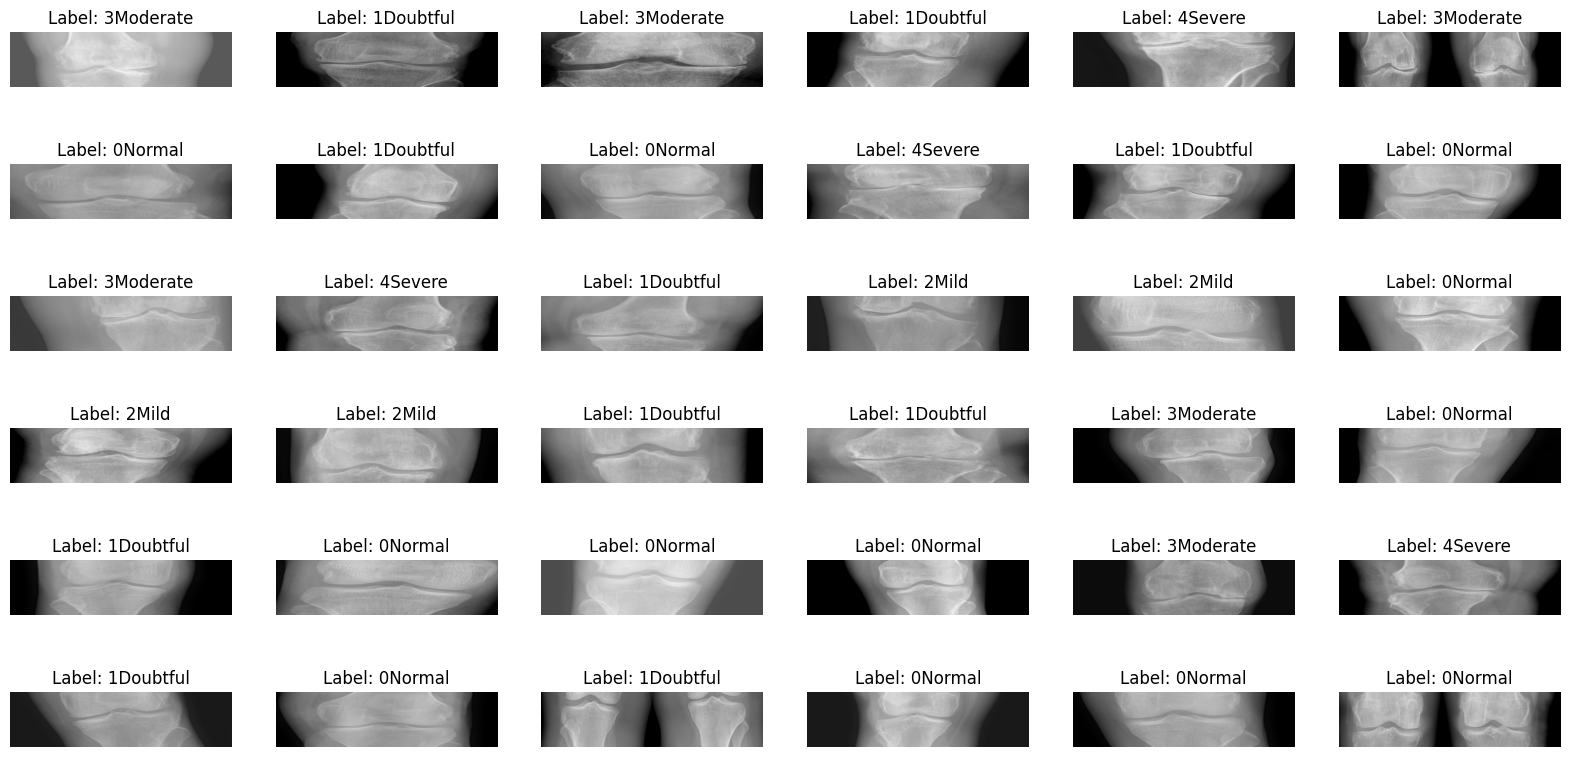

In [21]:
# Data visulization before Augmentation
plt.figure(figsize=(20, 10))
for i, (image, label) in enumerate(train_dataset.take(36)):
    image = image.numpy()  # Convert tensor to NumPy array

    plt.subplot(6, 6, i + 1)
    plt.imshow(image)
    plt.title(f"Label: {class_names[label]}")
    plt.axis("off")

plt.show()

# **Augmentation**

In [22]:
import tensorflow as tf
import albumentations as A
import numpy as np
import cv2
from collections import defaultdict

# Augmentations to apply
augmentations = [
    A.HorizontalFlip(p=1),
    A.VerticalFlip(p=1),
    A.Rotate(limit=(-45, 90), p=1),
    A.RandomCrop(height=154, width=576, p=1),  # 0.1 crop from 640x160
    A.RandomCrop(height=128, width=512, p=1),  # 0.2 crop from 640x160
    A.RandomGamma(gamma_limit=(80, 120), p=1),
    A.RandomBrightnessContrast(p=1),
    A.ChannelShuffle(p=1),
    A.InvertImg(p=1)
]

# Apply a random Augmentations from the Augmentations list
def apply_augmentations(image):
    image = image.numpy()
    aug = np.random.choice(augmentations)
    augmented_image = aug(image=image)["image"]
    augmented_image = cv2.resize(augmented_image, (640, 160))
    return augmented_image

# Required number of datapoints for each class
max_samples = 500

# Function to yield augmented dataset
def dataset_generator():
    for image, label in train_dataset:
        yield image, label.numpy()

    # Augment only required samples
    dataset_dict = defaultdict(list)
    for image, label in train_dataset:
        dataset_dict[label.numpy()].append(image)

    for class_id, images in dataset_dict.items():
        current_count = len(images)
        required_augmentations = max_samples - current_count
        img_idx = 0
        while required_augmentations > 0:
            img = images[img_idx % current_count]
            aug_img = apply_augmentations(img)
            yield aug_img, class_id
            required_augmentations -= 1
            img_idx += 1

# Create dataset from generator
balanced_train_dataset = tf.data.Dataset.from_generator(dataset_generator,
                                                  output_signature=(
                                                      tf.TensorSpec(shape=(160, 640, 3), dtype=tf.float32),
                                                      tf.TensorSpec(shape=(), dtype=tf.int32)
                                                  ))

In [23]:
# Class count after Augmentation
get_class_count(balanced_train_dataset)

Class 0: 500 images
Class 1: 500 images
Class 2: 500 images
Class 3: 500 images
Class 4: 500 images


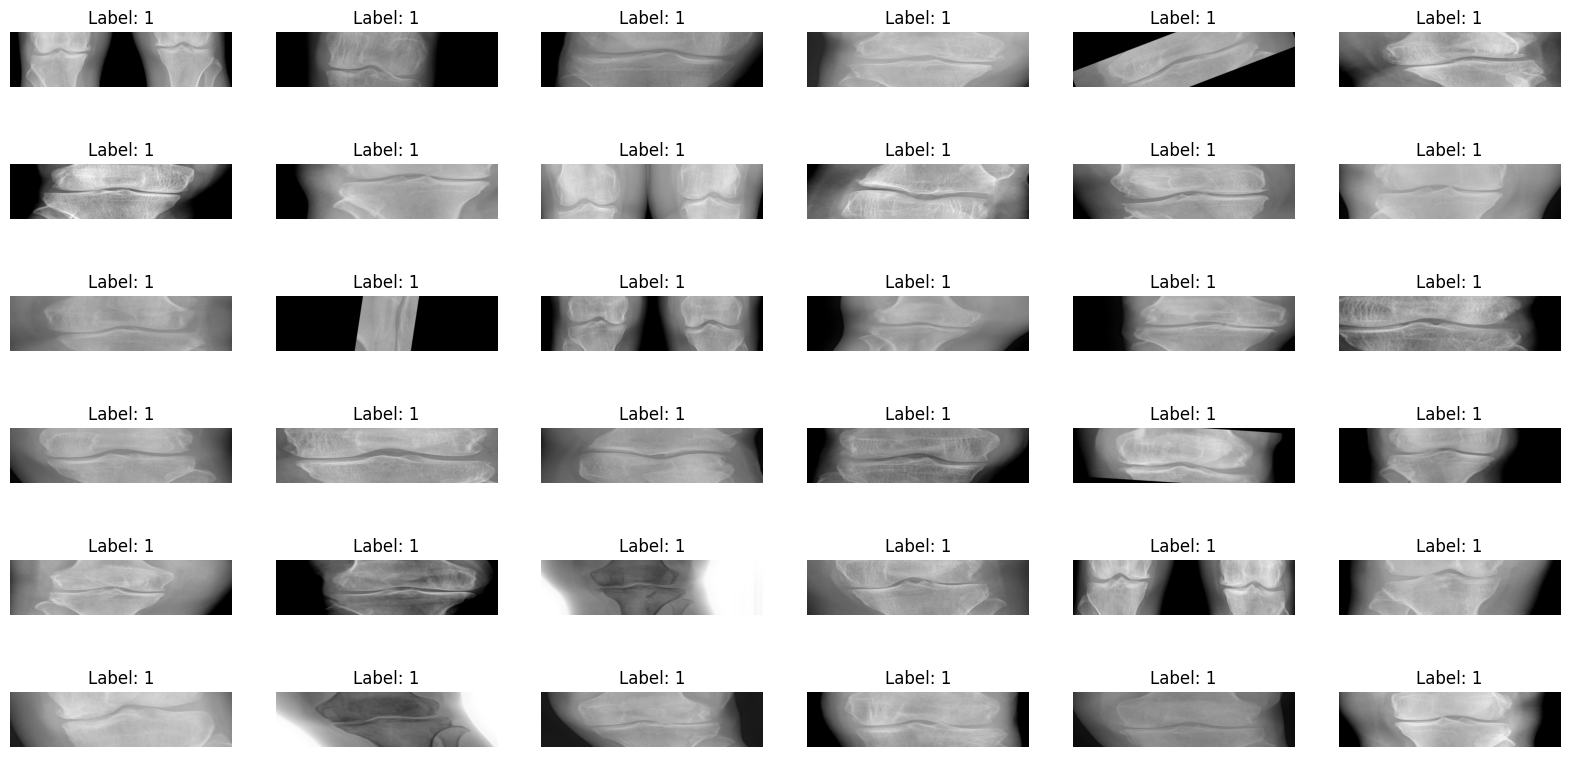

In [24]:
# Data Visualization after Augmentation
plt.figure(figsize=(20, 10))
for i, (image, label) in enumerate(balanced_train_dataset.skip(len(train_dataset)).take(36)):
    image = image.numpy()  # Convert tensor to NumPy array

    plt.subplot(6, 6, i + 1)
    plt.imshow(image)
    plt.title(f"Label: {label}")
    plt.axis("off")

plt.show()

In [25]:
# Calculate how many steps an epoch should run for
batch_size= 32
num_samples = sum(1 for _ in balanced_train_dataset)
steps_per_epoch = num_samples // batch_size

In [26]:
balanced_train_dataset = balanced_train_dataset.shuffle(500).repeat().batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.shuffle(500).batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.shuffle(500).batch(1).prefetch(tf.data.AUTOTUNE)

# **CallBacks**

In [19]:
#Saves the most with best performance among all epochs
checkpoint_path = "/content/best_model.keras"
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_sparse_categorical_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

In [20]:
#Reduces learning rate when there is no improvement in accuracy
learning_rate_callback = tf.keras.callbacks.ReduceLROnPlateau(
  monitor='val_sparse_categorical_accuracy',
  factor=0.3,
  patience=3,
  min_lr=1e-6,
  min_delta=0.01,
)

# **Model Architecture**

In [21]:
# Import pretrained EfficientNet from TensorFlow
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False, input_shape=(160, 640, 3), weights="imagenet"
)
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(5, activation="softmax")
])

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 5, 20, 1280)    │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,055,976 (15.47 MB)

 Trainable params: 4,013,953 (15.31 MB)

 Non-trainable params: 42,023 (164.16 KB)

#**Model Training**

In [23]:
from keras.losses import SparseCategoricalCrossentropy
from keras.optimizers import Adam
from keras.metrics import SparseCategoricalAccuracy

model.compile(optimizer = Adam(0.001),
              loss = SparseCategoricalCrossentropy(),
              metrics=[SparseCategoricalAccuracy()])

In [ ]:
history = model.fit(balanced_train_dataset,
                    validation_data = val_dataset,
                    epochs = 50,
                    steps_per_epoch = steps_per_epoch,
                    verbose = 1,
                    callbacks = [checkpoint_callback, learning_rate_callback])

Epoch 1/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - loss: 1.0419 - sparse_categorical_accuracy: 0.5782
Epoch 1: val_sparse_categorical_accuracy improved from -inf to 0.31212, saving model to /content/test_model.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 191s 1s/step - loss: 1.0403 - sparse_categorical_accuracy: 0.5791 - val_loss: 1.7737 - val_sparse_categorical_accuracy: 0.3121 - learning_rate: 0.0010
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step - loss: 0.7085 - sparse_categorical_accuracy: 0.7152
Epoch 2: val_sparse_categorical_accuracy did not improve from 0.31212
78/78 ━━━━━━━━━━━━━━━━━━━━ 27s 350ms/step - loss: 0.7082 - sparse_categorical_accuracy: 0.7154 - val_loss: 2.5775 - val_sparse_categorical_accuracy: 0.2879 - learning_rate: 0.0010
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step - loss: 0.5040 - sparse_categorical_accuracy: 0.8086
Epoch 3: val_sparse_categorical_accuracy did not improve from 0.31212
78/78 ━━━━━━━━━━━━━━━━━━━━ 27s 347ms/step - loss: 0.5038 - sparse_categor

#**Model Testing**

In [27]:
model = tf.keras.models.load_model("/content/test_model.keras")

In [28]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score

y_true = []
y_pred = []

# Get ground truth labels and predictions
for images, labels in test_dataset:
    preds = model.predict(images, verbose = 0)  # Get predictions
    preds = np.argmax(preds, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(preds)

# Convert lists to NumPy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [29]:
# Evaluating the model on the test dataset
model.evaluate(test_dataset)

165/165 ━━━━━━━━━━━━━━━━━━━━ 199s 1s/step - loss: 0.2960 - sparse_categorical_accuracy: 0.9205


[0.4331520199775696, 0.8848484754562378]

In [30]:
weighted_f1 = f1_score(y_true, y_pred, average='weighted')
print(f"Weighted F1 Score: {weighted_f1:.4f}")

Weighted F1 Score: 0.9264


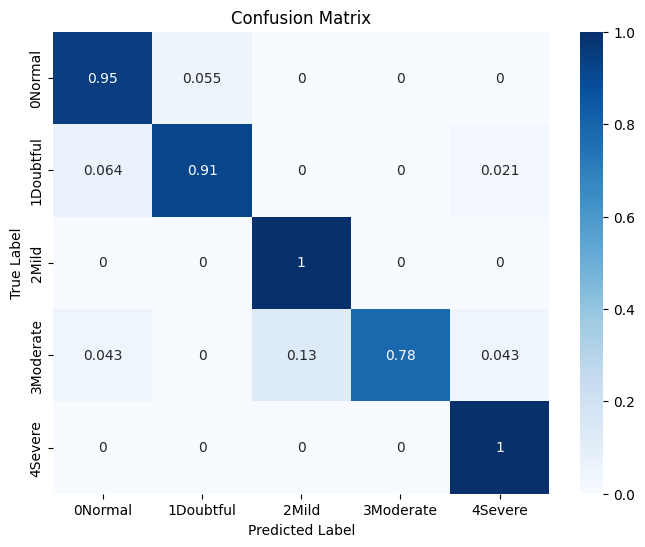

In [31]:
# Generate confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred, normalize="true")

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()